In [1]:
import pandas as pd
import os

csv_path = '/kaggle/input/competitions/airbus-ship-detection/train_ship_segmentations_v2.csv'

df = pd.read_csv(csv_path)

display(df.head())

,ImageId,EncodedPixels
0,00003e153.jpg,NaN
1,0001124c7.jpg,NaN
2,000155de5.jpg,264661 17 265429 33 266197 33 266965 33 267733...
3,000194a2d.jpg,360486 1 361252 4 362019 5 362785 8 363552 10 ...
4,000194a2d.jpg,51834 9 52602 9 53370 9 54138 9 54906 9 55674 ...


In [2]:
df["HasShip"] = df["EncodedPixels"].notnull().astype(int)
ships_per_image = df.groupby("ImageId")["HasShip"].sum().reset_index()
ships_per_image.columns = ["ImageId", "TotalShips"]

empty_images = (ships_per_image["TotalShips"] == 0).sum()
ship_images = (ships_per_image["TotalShips"] > 0).sum()

print(f"Total number of images: {len(ships_per_image)}")
print(f"Number of empty images: {empty_images}")
print(f"Number of images with at least one ship: {ship_images}")

Total number of images: 192556
Number of empty images: 150000
Number of images with at least one ship: 42556


In [3]:
df_ships = ships_per_image[ships_per_image["TotalShips"] > 0]
ship_counts = df_ships["TotalShips"].value_counts().sort_index()

print("Number of ships per image: ")
print(ship_counts) 

Number of ships per image: 
TotalShips
1     27104
2      7674
3      2954
4      1622
5       925
6       657
7       406
8       318
9       243
10      168
11      144
12      124
13       75
14       76
15       66
Name: count, dtype: int64


In [4]:
df_ships = df.dropna(subset = ["EncodedPixels"]).copy()
df_ships["ShipArea"] = df_ships["EncodedPixels"].apply(lambda x: sum([int(length) for length in x.split()[1::2]]))

print(f"Minimum ship area: {df_ships["ShipArea"].min()} pixels")
print(f"Maximum ship area: {df_ships["ShipArea"].max()} pixels")
print(f"Average Ship Area: {int(df_ships['ShipArea'].mean())} pixels")

Minimum ship area: 2 pixels
Maximum ship area: 25904 pixels
Average Ship Area: 1567 pixels


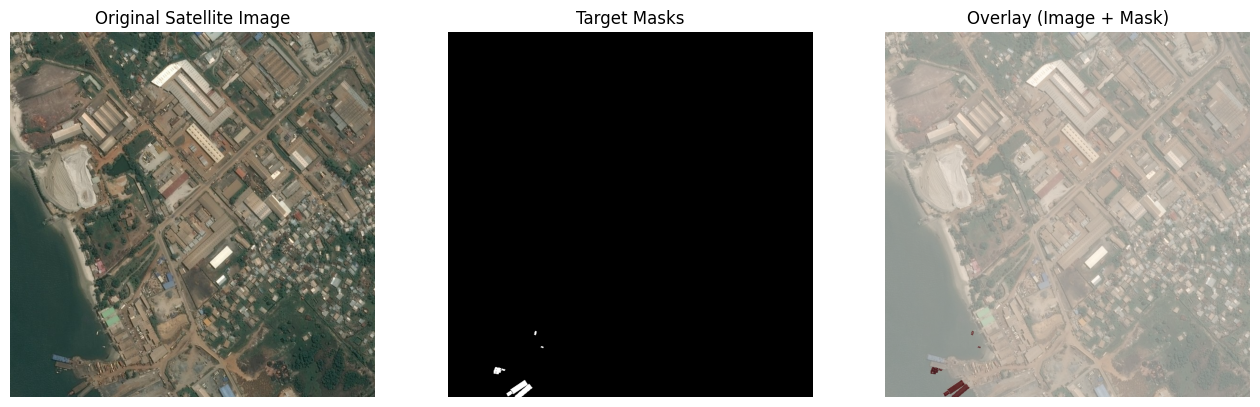

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from skimage.io import imread

def rle_decode(mask_rle, shape = (768, 768)):
    s = mask_rle.split()
    starts, lengths = [np.asarray(x, dtype = int) for x in (s[0:][::2], s[1:][::2])]
    starts -= 1
    ends = starts + lengths
    img = np.zeros(shape[0] * shape[1], dtype = np.uint8)
    for lo, hi in zip(starts, ends):
        img[lo:hi] = 1
    return img.reshape(shape).T

def get_mask(image_id, dataframe):
    rle_list = dataframe[dataframe["ImageId"] == image_id]["EncodedPixels"].tolist()
    all_masks = np.zeros((768, 768))
    for rle in rle_list:
        if pd.notna(rle):
            all_masks += rle_decode(rle)
    return all_masks

train_img_dir = '/kaggle/input/competitions/airbus-ship-detection/train_v2'
sample_image_id = df_ships["ImageId"].iloc[10]
img_path = os.path.join(train_img_dir, sample_image_id)

img = imread(img_path)
mask = get_mask(sample_image_id, df)

fig, ax = plt.subplots(1,3,figsize = (16,5))

ax[0].imshow(img)
ax[0].set_title('Original Satellite Image')
ax[0].axis('off')

ax[1].imshow(mask, cmap='gray')
ax[1].set_title('Target Masks')
ax[1].axis('off')

ax[2].imshow(img)
ax[2].imshow(mask, cmap='Reds', alpha=0.5) 
ax[2].set_title('Overlay (Image + Mask)')
ax[2].axis('off')

plt.show()

In [6]:
unique_ship_images = df_ships["ImageId"].unique()
df_positive_unique = pd.DataFrame({"ImageId": unique_ship_images})

df_empty = df[df["EncodedPixels"].isna()].copy()
df_empty = df_empty.drop_duplicates(subset = ["ImageId"])

num_ships = len(df_positive_unique)
df_empty_sampled = df_empty.sample(n = num_ships, random_state = 42)

print(f"Number of images with ships: {num_ships}")
print(f"Number of balanced empty images: {len(df_empty_sampled)}")


Number of images with ships: 42556
Number of balanced empty images: 42556


In [7]:
df_balanced = pd.concat([df_positive_unique, df_empty_sampled], ignore_index = True)
df_balanced = df_balanced.sample(frac = 1, random_state = 42).reset_index(drop = True)

print(f"Total balanced dataset size: {len(df_balanced)}")

Total balanced dataset size: 85112


In [24]:
import numpy as np
import tensorflow as tf
import os
import cv2
from tensorflow.keras.utils import Sequence

img_height = 256
img_width = 256
batch_size = 16
train_img_dir = "/kaggle/input/competitions/airbus-ship-detection/train_v2"

class AirbusDataGenerator(Sequence):
    def __init__(self, dataframe, image_dir, batch_size = 16, img_size = (256, 256), shuffle = True):
        self.df = dataframe
        self.image_dir = image_dir
        self.batch_size = batch_size
        self.img_size = img_size  
        self.shuffle = shuffle
        self.indexes = np.arange(len(self.df))
        self.on_epoch_end()

    def on_epoch_end(self):
        if self.shuffle == True:
            np.random.shuffle(self.indexes)

    def __len__(self):
        return int(np.floor(len(self.df) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_df = self.df.iloc[batch_indexes]
    
        x = np.empty((self.batch_size, self.img_size[0], self.img_size[1], 3), dtype = np.float32)
        y = np.empty((self.batch_size, self.img_size[0], self.img_size[1], 1), dtype = np.float32)

        for i, (_, row) in enumerate(batch_df.iterrows()):
            image_id = row["ImageId"]
            img_path = os.path.join(self.image_dir, image_id)

            img = imread(img_path)
            img_resized = tf.image.resize(img, self.img_size).numpy() / 255.0
            
            mask = get_mask(image_id, df)

            mask_expanded = np.expand_dims(mask, axis = -1)
            mask_resized = tf.image.resize(mask_expanded, self.img_size).numpy()

            x[i] = img_resized
            y[i] = mask_resized

        return x, y

In [25]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df_balanced, test_size = 0.2, random_state = 42)

train_generator = AirbusDataGenerator(
    dataframe = train_df,
    image_dir = train_img_dir,
    batch_size = 16,
    img_size = (256, 256),
    shuffle = True
)

x_batch, y_batch = train_generator[0]

print(f"x_batch size: {x_batch.shape}")
print(f"y_batch size: {y_batch.shape}")

x_batch size: (16, 256, 256, 3)
y_batch size: (16, 256, 256, 1)


In [26]:
import tensorflow.keras.backend as K 

def dice_coef(y_true, y_pred, smooth = 1):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

In [27]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Conv2DTranspose, concatenate
from tensorflow.keras.optimizers import Adam



def build_unet(input_shape=(256, 256, 3)):
    inputs = Input(input_shape)

    c1 = Conv2D(16, (3, 3), activation='relu', padding='same')(inputs)
    c1 = Conv2D(16, (3, 3), activation='relu', padding='same')(c1)
    p1 = MaxPooling2D((2, 2))(c1)

    c2 = Conv2D(32, (3, 3), activation='relu', padding='same')(p1)
    c2 = Conv2D(32, (3, 3), activation='relu', padding='same')(c2)
    p2 = MaxPooling2D((2, 2))(c2)

    c3 = Conv2D(64, (3, 3), activation='relu', padding='same')(p2)
    c3 = Conv2D(64, (3, 3), activation='relu', padding='same')(c3)

    u4 = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c3)
    u4 = concatenate([u4, c2]) 
    c4 = Conv2D(32, (3, 3), activation='relu', padding='same')(u4)
    c4 = Conv2D(32, (3, 3), activation='relu', padding='same')(c4)

    u5 = Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c4)
    u5 = concatenate([u5, c1]) 
    c5 = Conv2D(16, (3, 3), activation='relu', padding='same')(u5)
    c5 = Conv2D(16, (3, 3), activation='relu', padding='same')(c5)

    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c5)

    model = Model(inputs=[inputs], outputs=[outputs])
    return model


model = build_unet()

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=dice_loss,
    metrics=[dice_coef, "accuracy"]
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 256, 256,  │        448 │ input_layer_6[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 256, 256,  │      2,320 │ conv2d_39[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 128, 128,  │          0 │ conv2d_40[0][0]   │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_41 (Conv2D)  │ (None, 128, 128,  │      4,640 │ max_pooling2d_8[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_42 (Conv2D)  │ (None, 128, 128,  │      9,248 │ conv2d_41[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 64, 64,    │          0 │ conv2d_42[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_43 (Conv2D)  │ (None, 64, 64,    │     18,496 │ max_pooling2d_9[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_44 (Conv2D)  │ (None, 64, 64,    │     36,928 │ conv2d_43[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_6  │ (None, 128, 128,  │      8,224 │ conv2d_44[0][0]   │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 128, 128,  │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 64)               │            │ conv2d_42[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_45 (Conv2D)  │ (None, 128, 128,  │     18,464 │ concatenate_6[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_46 (Conv2D)  │ (None, 128, 128,  │      9,248 │ conv2d_45[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_7  │ (None, 256, 256,  │      2,064 │ conv2d_46[0][0]   │
│ (Conv2DTranspose)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 256, 256,  │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 32)               │            │ conv2d_40[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_47 (Conv2D)  │ (None, 256, 256,  │      4,624 │ concatenate_7[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_48 (Conv2D)  │ (None, 256, 256,  │      2,320 │ conv2d_47[0][0] 

 Total params: 117,041 (457.19 KB)

 Trainable params: 117,041 (457.19 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
val_generator = AirbusDataGenerator(
    dataframe = val_df,
    image_dir = train_img_dir,
    batch_size = 16,
    img_size = (256, 256),
    shuffle = False
)

print("2 epoch starting..")

history = model.fit(
    train_generator,
    validation_data = val_generator,
    epochs = 2
)

2 epoch starting..


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/2


2026-08-08 18:59:44.360622: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-08 18:59:44.505457: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-08 18:59:46.871092: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-08 18:59:47.154219: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-08 18:59:47.889018: E external/local_xla/xla/stream_

   2/4255 ━━━━━━━━━━━━━━━━━━━━ 7:09 101ms/step - accuracy: 0.3652 - dice_coef: 0.0048 - loss: 0.9952  

I0000 00:00:1786215596.056085     131 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


4255/4255 ━━━━━━━━━━━━━━━━━━━━ 0s 672ms/step - accuracy: 0.8646 - dice_coef: 0.0035 - loss: 0.9965

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


4255/4255 ━━━━━━━━━━━━━━━━━━━━ 3551s 830ms/step - accuracy: 0.9661 - dice_coef: 0.0016 - loss: 0.9984 - val_accuracy: 0.9974 - val_dice_coef: 6.1043e-04 - val_loss: 0.9994
Epoch 2/2
4255/4255 ━━━━━━━━━━━━━━━━━━━━ 2969s 698ms/step - accuracy: 0.9975 - dice_coef: 6.3817e-04 - loss: 0.9994 - val_accuracy: 0.9974 - val_dice_coef: 6.1066e-04 - val_loss: 0.9994
